# Adaptive Cognitive UI

AI akan mengklasifikasikan pengguna MSME pedesaan ASEAN ke dalam 4 profil UI berdasarkan perilaku interaksi mereka dengan aplikasi. Notebook ini menghasilkan data sintetis untuk fitur Adaptive Cognitive UI.

Profil UI:
- Guided -> Pengguna lansia / pertama kali digital, butuh panduan penuh
- Simplified -> Pengguna yang paham dasar tapi kesulitan di alur multi-langkah
- Standard -> Pengguna smartphone yang nyaman dengan pola UI standar
- Efficient -> Pengguna mahir teknologi, butuh UI kompak dan cepat

Ringkasan Data:
- users -> 5000 data (dari datas/users.csv)
- ui_behavior_sessions -> 100.000 data (5000 user x 20 sesi)
- ui_profiles -> 5000 data (mapping user ke profil UI)
- Aggregated features -> 5000 data (untuk XGBoost)
- Sequence tensors -> (5000, 20, 14) tensor (untuk LSTM/GRU)

# Data Generation

## Setup

### Environment Setup

In [5]:
import numpy as np
import pandas as pd
import json
import os
import torch
import warnings
from datetime import datetime, timedelta
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

### Configuration

In [31]:
"""
Global configuration untuk Adaptive Cognitive UI data generation.
"""

config = {
    'num_users': 5000,
    'sessions_per_user': 20,
    'num_session_features': 14,
    'random_seed': 42,

    'train_split': 0.70,
    'val_split': 0.15,
    'test_split': 0.15,

    'profile_labels': {
        0: 'guided',
        1: 'simplified',
        2: 'standard',
        3: 'efficient'
    },

    'class_names': ['guided', 'simplified', 'standard', 'efficient'],

    'target_distribution': {
        'guided': 0.15,
        'simplified': 0.30,
        'standard': 0.35,
        'efficient': 0.20
    },

    'session_feature_names': [
        'hesitation_time_ms',
        'back_button_per_session',
        'rapid_back_sequences',
        'scroll_speed_px_s',
        'scroll_direction_changes',
        'scroll_overshoot_rate',
        'abandon_rate',
        'tap_precision_score',
        'double_tap_rate',
        'time_between_actions_ms',
        'feature_usage_breadth',
        'session_duration_sec',
        'error_encounter_rate',
        'help_button_usage'
    ],

    'num_classes': 4,
    'batch_size': 64,
    'num_epochs': 100,
    'patience': 15,
    'learning_rate': 1e-3,
    'weight_decay': 1e-4,

    'lstm_hidden_size': 64,
    'gru_hidden_size': 64,
    'num_rnn_layers': 2,
    'rnn_dropout': 0.3,
    'bidirectional': True,

    'xgb_n_estimators': 300,
    'xgb_max_depth': 6,
    'xgb_learning_rate': 0.05,
    'xgb_subsample': 0.8,
    'xgb_colsample_bytree': 0.8
}

np.random.seed(config['random_seed'])
torch.manual_seed(config['random_seed'])

f"Configuration loaded: {config['num_users']} users, {config['sessions_per_user']} sessions each, {config['num_session_features']} features per session"

'Configuration loaded: 5000 users, 20 sessions each, 14 features per session'

### Path Setup

In [7]:
"""Base path ke folder datas (relatif dari notebook ini di AI-Lab/model-dev/)"""
datas_path = '../datas'
models_path = '../models'

Path(f'{datas_path}').mkdir(parents=True, exist_ok=True)
Path(f'{models_path}').mkdir(parents=True, exist_ok=True)

f"Paths ready: datas={os.path.abspath(datas_path)}, models={os.path.abspath(models_path)}"

'Paths ready: datas=/home/azril/Personal/Projects/DSAI/Asean Singapore Hackathon/AI-Lab/datas, models=/home/azril/Personal/Projects/DSAI/Asean Singapore Hackathon/AI-Lab/models'

## User Data

### Load Existing Users

In [9]:
users = pd.read_csv(f'{datas_path}/users.csv')

"""Tambahkan user_id numerik berdasarkan nama"""
users['user_id'] = users['name'].str.extract(r'(\d+)').astype(int)

print(f"Loaded {len(users)} users from datas/users.csv")
print(f"\nColumns: {list(users.columns)}")
print(f"Age: mean={users['age'].mean():.1f}, range=[{users['age'].min()}, {users['age'].max()}]")
print(f"Occupation codes: {sorted(users['occupation'].unique())}")
print(f"Income: mean={users['monthly_income'].mean():,.0f}")

users.head(10)

Loaded 5000 users from datas/users.csv

Columns: ['name', 'age', 'occupation', 'monthly_income', 'social_status', 'location', 'credit_score', 'user_id']
Age: mean=31.4, range=[18, 45]
Occupation codes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
Income: mean=1,560,403


,name,age,occupation,monthly_income,social_status,location,credit_score,user_id
0,name-1,37,10,565569,0,5,0.406204,1
1,name-2,27,1,547271,0,4,0.765431,2
2,name-3,27,4,853682,0,5,0.588724,3
3,name-4,40,1,850212,4,1,0.736884,4
4,name-5,41,8,1001754,1,3,0.706347,5
5,name-6,44,1,954224,2,5,0.583491,6
6,name-7,31,0,755441,0,1,0.410600,7
7,name-8,32,9,1480122,2,3,0.371651,8
8,name-9,31,7,2934045,1,5,0.638244,9
9,name-10,26,5,865649,0,4,0.364402,10


### Digital Literacy Score

Digital Literacy Score Statistics:
  Mean: 0.535
  Std:  0.119
  Min:  0.052
  Max:  1.000


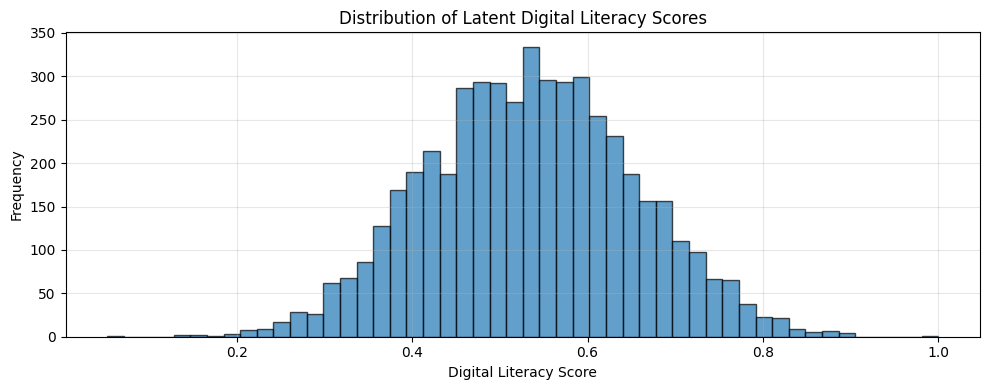

In [10]:
"""
Latent variable: digunakan untuk menentukan ground truth UI profile.
Faktor penentu: age (negatif), occupation modifier, monthly_income (positif), credit_score (positif), dan noise.
"""

occupation_tech_modifier = {
    0: -0.10,
    1: -0.08,
    2: 0.05,
    3: 0.00,
    4: -0.05,
    5: 0.03,
    6: 0.15,
    7: 0.05,
    8: -0.03,
    9: -0.12,
    10: 0.00
}

digital_literacy_scores = []

for _, row in users.iterrows():
    """Age component: younger = higher score (normalized 0-1)"""
    age_component = 1.0 - ((row['age'] - 18) / (75 - 18))
    age_component = np.clip(age_component, 0.0, 1.0)

    """Income component (normalized by reasonable max)"""
    income_component = min(row['monthly_income'] / 2_000_000, 1.0)

    """Credit score sebagai proxy digital maturity"""
    credit_component = float(row['credit_score'])

    """Occupation tech modifier"""
    occ_modifier = occupation_tech_modifier.get(row['occupation'], 0.0)

    """Weighted combination + noise"""
    raw_score = (
        0.25 * age_component +
        0.20 * income_component +
        0.20 * credit_component +
        0.15 * occ_modifier +
        0.20 * np.random.beta(2, 2)
    )

    """Noise untuk mencegah mapping deterministik"""
    noise = np.random.normal(0, 0.08)
    final_score = np.clip(raw_score + noise, 0.0, 1.0)

    digital_literacy_scores.append(final_score)

users['digital_literacy_score'] = digital_literacy_scores

print(f"Digital Literacy Score Statistics:")
print(f"  Mean: {users['digital_literacy_score'].mean():.3f}")
print(f"  Std:  {users['digital_literacy_score'].std():.3f}")
print(f"  Min:  {users['digital_literacy_score'].min():.3f}")
print(f"  Max:  {users['digital_literacy_score'].max():.3f}")

plt.figure(figsize=(10, 4))
plt.hist(users['digital_literacy_score'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Digital Literacy Score')
plt.ylabel('Frequency')
plt.title('Distribution of Latent Digital Literacy Scores')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### UI Profile Assignment

In [11]:
"""
Assign UI profile berdasarkan digital_literacy_score dengan soft boundaries.
"""

def assign_ui_profile(score):
    """Assign profile dengan stochastic boundary overlap"""
    boundaries = [
        (0.00, 0.22, 'guided'),
        (0.18, 0.47, 'simplified'),
        (0.43, 0.77, 'standard'),
        (0.73, 1.00, 'efficient')
    ]

    """Tentukan profil mana yang bisa diterima berdasarkan score"""
    candidates = []
    for low, high, profile in boundaries:
        if low <= score <= high:
            """Weight berdasarkan seberapa sentral score dalam range"""
            center = (low + high) / 2
            distance = abs(score - center) / ((high - low) / 2)
            weight = max(0.1, 1.0 - distance)
            candidates.append((profile, weight))

    if not candidates:
        if score < 0.20:
            return 'guided'
        return 'efficient'

    profiles = [c[0] for c in candidates]
    weights = np.array([c[1] for c in candidates])
    weights = weights / weights.sum()

    return np.random.choice(profiles, p=weights)


users['ui_profile'] = users['digital_literacy_score'].apply(assign_ui_profile)

profile_to_label = {'guided': 0, 'simplified': 1, 'standard': 2, 'efficient': 3}
users['ui_profile_label'] = users['ui_profile'].map(profile_to_label)

print("UI Profile Distribution:")
dist = users['ui_profile'].value_counts(normalize=True).round(3)
for profile in ['guided', 'simplified', 'standard', 'efficient']:
    count = (users['ui_profile'] == profile).sum()
    pct = dist.get(profile, 0)
    print(f"  {profile:12s}: {count:5d} ({pct:.1%})")

UI Profile Distribution:
  guided      :    10 (0.2%)
  simplified  :  1233 (24.7%)
  standard    :  3569 (71.4%)
  efficient   :   188 (3.8%)


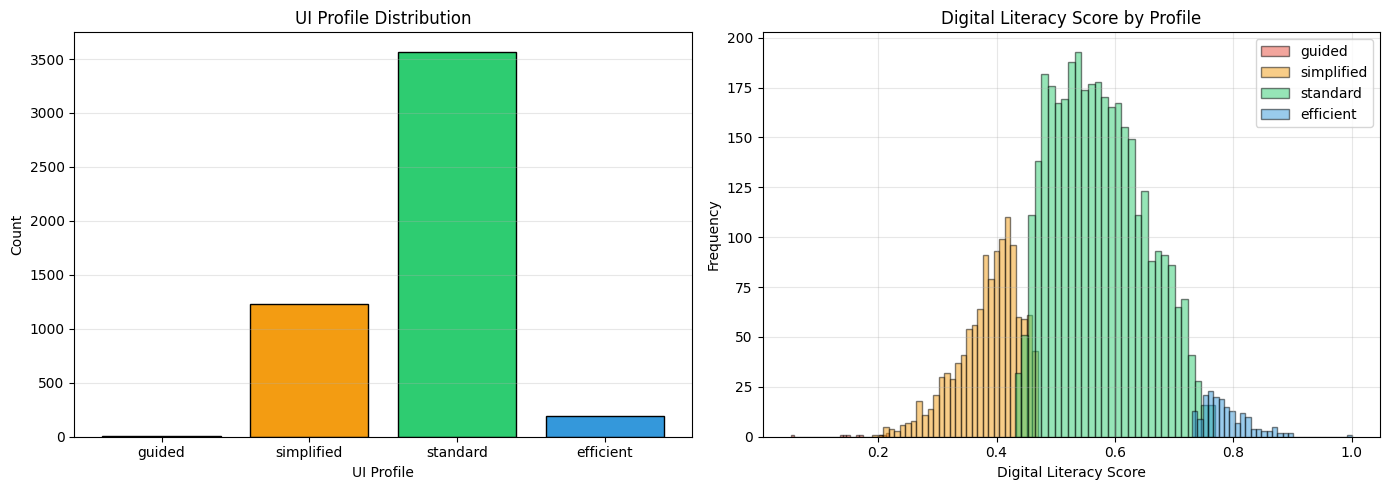

In [12]:
"""
Visualisasi distribusi profil dan hubungan dengan digital literacy score.
"""

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

profile_order = ['guided', 'simplified', 'standard', 'efficient']
colors = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']

profile_counts = users['ui_profile'].value_counts().reindex(profile_order)
axes[0].bar(profile_order, profile_counts.values, color=colors, edgecolor='black')
axes[0].set_xlabel('UI Profile')
axes[0].set_ylabel('Count')
axes[0].set_title('UI Profile Distribution')
axes[0].grid(True, alpha=0.3, axis='y')

for profile, color in zip(profile_order, colors):
    subset = users[users['ui_profile'] == profile]['digital_literacy_score']
    axes[1].hist(subset, bins=30, alpha=0.5, label=profile, color=color, edgecolor='black')

axes[1].set_xlabel('Digital Literacy Score')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Digital Literacy Score by Profile')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Behavioral Data Generation

### Profile Parameter Definitions

In [13]:
"""
Mendefinisikan range parameter perilaku untuk setiap UI profile.
Setiap fitur memiliki (min, max) range yang berbeda per profil.
"""

profile_params = {
    'guided': {
        'hesitation_time_ms':       (5000, 12000),
        'back_button_per_session':  (5, 15),
        'rapid_back_sequences':     (2, 5),
        'scroll_speed_px_s':        (50, 200),
        'scroll_direction_changes': (5, 12),
        'scroll_overshoot_rate':    (0.30, 0.60),
        'abandon_rate':             (0.40, 0.80),
        'tap_precision_score':      (0.40, 0.65),
        'double_tap_rate':          (0.15, 0.40),
        'time_between_actions_ms':  (4000, 10000),
        'feature_usage_breadth':    (1, 3),
        'session_duration_sec':     (60, 180),
        'error_encounter_rate':     (0.20, 0.50),
        'help_button_usage':        (3, 8)
    },
    'simplified': {
        'hesitation_time_ms':       (2000, 5000),
        'back_button_per_session':  (2, 6),
        'rapid_back_sequences':     (0, 2),
        'scroll_speed_px_s':        (200, 500),
        'scroll_direction_changes': (2, 5),
        'scroll_overshoot_rate':    (0.10, 0.30),
        'abandon_rate':             (0.15, 0.40),
        'tap_precision_score':      (0.65, 0.80),
        'double_tap_rate':          (0.05, 0.15),
        'time_between_actions_ms':  (2000, 4000),
        'feature_usage_breadth':    (3, 5),
        'session_duration_sec':     (180, 480),
        'error_encounter_rate':     (0.08, 0.20),
        'help_button_usage':        (1, 3)
    },
    'standard': {
        'hesitation_time_ms':       (800, 2000),
        'back_button_per_session':  (0, 2),
        'rapid_back_sequences':     (0, 0),
        'scroll_speed_px_s':        (500, 1200),
        'scroll_direction_changes': (0, 2),
        'scroll_overshoot_rate':    (0.02, 0.10),
        'abandon_rate':             (0.02, 0.15),
        'tap_precision_score':      (0.80, 0.95),
        'double_tap_rate':          (0.00, 0.05),
        'time_between_actions_ms':  (800, 2000),
        'feature_usage_breadth':    (5, 8),
        'session_duration_sec':     (300, 900),
        'error_encounter_rate':     (0.01, 0.08),
        'help_button_usage':        (0, 1)
    },
    'efficient': {
        'hesitation_time_ms':       (200, 800),
        'back_button_per_session':  (0, 1),
        'rapid_back_sequences':     (0, 0),
        'scroll_speed_px_s':        (1200, 3000),
        'scroll_direction_changes': (0, 1),
        'scroll_overshoot_rate':    (0.00, 0.02),
        'abandon_rate':             (0.00, 0.02),
        'tap_precision_score':      (0.95, 1.00),
        'double_tap_rate':          (0.00, 0.00),
        'time_between_actions_ms':  (200, 800),
        'feature_usage_breadth':    (8, 12),
        'session_duration_sec':     (120, 600),
        'error_encounter_rate':     (0.00, 0.01),
        'help_button_usage':        (0, 0)
    }
}

"""Occupation based modifiers menggunakan kode integer dari users.csv"""
occupation_behavior_modifier = {
    0:  {'session_duration_sec': 0.7, 'feature_usage_breadth': 0.8},
    1:  {'session_duration_sec': 0.6, 'feature_usage_breadth': 0.7},
    2:  {'session_duration_sec': 1.1, 'feature_usage_breadth': 1.1},
    3:  {'session_duration_sec': 0.9, 'feature_usage_breadth': 0.9},
    4:  {'session_duration_sec': 0.8, 'feature_usage_breadth': 0.8},
    5:  {'session_duration_sec': 1.0, 'feature_usage_breadth': 1.0},
    6:  {'session_duration_sec': 0.8, 'feature_usage_breadth': 1.2},
    7:  {'session_duration_sec': 1.0, 'feature_usage_breadth': 1.0},
    8:  {'session_duration_sec': 0.7, 'feature_usage_breadth': 0.85},
    9:  {'session_duration_sec': 0.6, 'feature_usage_breadth': 0.75},
    10: {'session_duration_sec': 0.9, 'feature_usage_breadth': 0.9}
}

f"Defined behavioral parameters for {len(profile_params)} profiles with {len(config['session_feature_names'])} features each"

'Defined behavioral parameters for 4 profiles with 14 features each'

### Per Session Behavioral Data

In [14]:
"""
Generate data perilaku per sesi untuk setiap user.
Setiap user mendapat per user random multiplier (dari np.random.beta) agar ada variasi antar individu dalam profil yang sama.
Occupation juga memodifikasi beberapa fitur (durasi sesi, breadth penggunaan fitur).
Noise session to session ditambahkan dengan np.random.normal.
Total output: 5000 users x 20 sessions = 100.000 records.
"""

all_sessions = []

for _, user in users.iterrows():
    profile = user['ui_profile']
    occupation = user['occupation']
    params = profile_params[profile]
    occ_mod = occupation_behavior_modifier.get(occupation, {})

    """Per-user random multiplier untuk cross-user variance"""
    user_multiplier = np.random.beta(5, 5)

    for session_idx in range(config['sessions_per_user']):
        session_data = {
            'user_id': user['user_id'],
            'session_idx': session_idx
        }

        for feature_name in config['session_feature_names']:
            f_min, f_max = params[feature_name]

            """Base value menggunakan per-user multiplier dalam range"""
            base_value = f_min + user_multiplier * (f_max - f_min)

            """Session-to-session noise"""
            noise_scale = (f_max - f_min) * 0.15
            session_noise = np.random.normal(0, noise_scale)
            value = base_value + session_noise

            """Terapkan occupation modifier jika ada"""
            if feature_name in occ_mod:
                value *= occ_mod[feature_name]

            """Clip ke range yang valid"""
            if feature_name in ['scroll_overshoot_rate', 'abandon_rate', 'tap_precision_score',
                                'double_tap_rate', 'error_encounter_rate']:
                value = np.clip(value, 0.0, 1.0)
            elif feature_name in ['back_button_per_session', 'rapid_back_sequences',
                                  'scroll_direction_changes', 'feature_usage_breadth',
                                  'help_button_usage']:
                value = max(0, round(value))
            else:
                value = max(0, value)

            session_data[feature_name] = value

        all_sessions.append(session_data)

sessions_df = pd.DataFrame(all_sessions)

print(f"Generated {len(sessions_df)} session records")
print(f"Users: {sessions_df['user_id'].nunique()}")
print(f"Sessions per user: {sessions_df.groupby('user_id').size().mean():.0f}")
print(f"\nFeature statistics (mean across all sessions):")
for feat in config['session_feature_names']:
    print(f"  {feat:30s}: {sessions_df[feat].mean():10.2f}  (std={sessions_df[feat].std():.2f})")

Generated 100000 session records
Users: 5000
Sessions per user: 20

Feature statistics (mean across all sessions):
  hesitation_time_ms            :    1894.52  (std=1053.92)
  back_button_per_session       :       1.73  (std=1.48)
  rapid_back_sequences          :       0.25  (std=0.51)
  scroll_speed_px_s             :     772.30  (std=374.28)
  scroll_direction_changes      :       1.61  (std=1.25)
  scroll_overshoot_rate         :       0.09  (std=0.07)
  abandon_rate                  :       0.13  (std=0.09)
  tap_precision_score           :       0.84  (std=0.08)
  double_tap_rate               :       0.04  (std=0.04)
  time_between_actions_ms       :    1768.12  (std=821.27)
  feature_usage_breadth         :       5.47  (std=1.69)
  session_duration_sec          :     433.08  (std=164.61)
  error_encounter_rate          :       0.07  (std=0.05)
  help_button_usage             :       0.86  (std=0.85)


In [15]:
"""
Verifikasi distribusi fitur berbeda antar profil.
"""

sessions_with_profile = sessions_df.merge(
    users[['user_id', 'ui_profile']],
    on='user_id'
)

print("Per-profile mean values for key features:")
print("=" * 80)

key_features = ['hesitation_time_ms', 'back_button_per_session', 'tap_precision_score',
                'scroll_speed_px_s', 'abandon_rate', 'session_duration_sec']

profile_means = sessions_with_profile.groupby('ui_profile')[key_features].mean()
profile_means = profile_means.reindex(['guided', 'simplified', 'standard', 'efficient'])

print(profile_means.round(2).to_string())

Per-profile mean values for key features:
            hesitation_time_ms  back_button_per_session  tap_precision_score  scroll_speed_px_s  abandon_rate  session_duration_sec
ui_profile                                                                                                                         
guided                 8124.44                     9.59                 0.52             121.48          0.59                 79.79
simplified             3492.22                     3.98                 0.72             348.58          0.27                268.37
standard               1398.08                     1.00                 0.87             849.22          0.08                497.20
efficient               509.13                     0.52                 0.98            2125.49          0.01                314.81


## Export Data

In [16]:
"""Session behavioral data"""
sessions_df.to_csv(f'{datas_path}/ui-behavior-sessions.csv', index=False)
print(f"Saved: ui-behavior-sessions.csv ({len(sessions_df)} rows)")

"""User to profile mapping"""
profiles_export = users[['user_id', 'name', 'ui_profile', 'ui_profile_label']].copy()
profiles_export.to_csv(f'{datas_path}/ui-profiles.csv', index=False)
print(f"Saved: ui-profiles.csv ({len(profiles_export)} rows)")

Saved: ui-behavior-sessions.csv (100000 rows)
Saved: ui-profiles.csv (5000 rows)


## Summary

In [17]:
"""Summary data generation"""

print(f"\nUsers loaded from: {datas_path}/users.csv ({len(users)})")
print(f"Total sessions generated: {len(sessions_df)}")
print(f"Session features: {config['num_session_features']}")
print(f"\nProfile distribution:")
for profile in ['guided', 'simplified', 'standard', 'efficient']:
    count = int((users['ui_profile'] == profile).sum())
    print(f"  {profile:12s}: {count:5d} ({count/len(users):.1%})")
print(f"\nRaw data exported to: {os.path.abspath(datas_path)}/")
print(f"  - ui-behavior-sessions.csv")
print(f"  - ui-profiles.csv")


Users loaded from: ../datas/users.csv (5000)
Total sessions generated: 100000
Session features: 14

Profile distribution:
  guided      :    10 (0.2%)
  simplified  :  1233 (24.7%)
  standard    :  3569 (71.4%)
  efficient   :   188 (3.8%)

Raw data exported to: /home/azril/Personal/Projects/DSAI/Asean Singapore Hackathon/AI-Lab/datas/
  - ui-behavior-sessions.csv
  - ui-profiles.csv


# Modeling

## Setup

In [20]:
"""Import tambahan untuk modeling"""

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)
from sklearn.manifold import TSNE

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## Feature Engineering

### Aggregated Features for XGBoost

In [21]:
"""
Aggregate per user: hitung mean, median, std, min, max untuk setiap session feature.
14 fitur x 5 statistik = 70 fitur + 1 (sessions_count) = 71 fitur per user.
"""

feature_cols = config['session_feature_names']

agg_funcs = ['mean', 'median', 'std', 'min', 'max']
agg_dict = {feat: agg_funcs for feat in feature_cols}

aggregated = sessions_df.groupby('user_id').agg(agg_dict)
aggregated.columns = [f'{feat}_{stat}' for feat, stat in aggregated.columns]
aggregated = aggregated.reset_index()

"""Tambahkan session count"""
session_counts = sessions_df.groupby('user_id').size().reset_index(name='sessions_count')
aggregated = aggregated.merge(session_counts, on='user_id')

"""Merge dengan label"""
aggregated = aggregated.merge(
    users[['user_id', 'ui_profile', 'ui_profile_label']],
    on='user_id'
)

"""Fill NaN std values"""
aggregated = aggregated.fillna(0)

feature_columns = [c for c in aggregated.columns if c not in ['user_id', 'ui_profile', 'ui_profile_label']]

print(f"Aggregated dataset shape: {aggregated.shape}")
print(f"Number of features: {len(feature_columns)}")
print(f"\nSample features: {feature_columns[:10]}")

aggregated.head()

Aggregated dataset shape: (5000, 74)
Number of features: 71

Sample features: ['hesitation_time_ms_mean', 'hesitation_time_ms_median', 'hesitation_time_ms_std', 'hesitation_time_ms_min', 'hesitation_time_ms_max', 'back_button_per_session_mean', 'back_button_per_session_median', 'back_button_per_session_std', 'back_button_per_session_min', 'back_button_per_session_max']


,user_id,hesitation_time_ms_mean,hesitation_time_ms_median,hesitation_time_ms_std,hesitation_time_ms_min,hesitation_time_ms_max,back_button_per_session_mean,back_button_per_session_median,back_button_per_session_std,back_button_per_session_min,...,error_encounter_rate_min,error_encounter_rate_max,help_button_usage_mean,help_button_usage_median,help_button_usage_std,help_button_usage_min,help_button_usage_max,sessions_count,ui_profile,ui_profile_label
0,1,3220.597120,3225.741634,400.126921,2436.815228,4051.156037,3.70,4.0,0.801315,2,...,0.104356,0.180090,2.00,2.0,0.000000,2,2,20,simplified,1
1,2,1641.364904,1681.794660,193.137759,1318.023863,2102.270577,1.20,1.0,0.410391,1,...,0.042168,0.067194,0.95,1.0,0.223607,0,1,20,standard,2
2,3,1301.602146,1344.444953,215.197606,787.457149,1743.647321,1.00,1.0,0.324443,0,...,0.014117,0.060667,0.20,0.0,0.410391,0,1,20,standard,2
3,4,3976.843475,3898.402809,348.222712,3438.705280,4643.425914,4.50,4.5,0.512989,4,...,0.120726,0.194664,2.40,2.0,0.502625,2,3,20,simplified,1
4,5,1461.405161,1446.951388,161.902520,1133.407511,1712.164928,0.95,1.0,0.223607,0,...,0.020178,0.060221,0.40,0.0,0.502625,0,1,20,standard,2


### Sequence Features for LSTM/GRU

In [22]:
"""
Shape: (num_users, sessions_per_user, num_features) = (5000, 20, 14)
Setiap timestep merepresentasikan satu sesi interaksi user.
"""

num_users = config['num_users']
seq_len = config['sessions_per_user']
num_features = config['num_session_features']

sequences = np.zeros((num_users, seq_len, num_features))
labels = np.zeros(num_users, dtype=np.int64)
user_ids_ordered = []

for idx, (user_id, group) in enumerate(sessions_df.groupby('user_id')):
    group_sorted = group.sort_values('session_idx')
    feature_values = group_sorted[feature_cols].values

    """Pad atau truncate ke fixed length"""
    actual_len = min(len(feature_values), seq_len)
    sequences[idx, :actual_len, :] = feature_values[:actual_len]

    user_label = users[users['user_id'] == user_id]['ui_profile_label'].values[0]
    labels[idx] = user_label
    user_ids_ordered.append(user_id)

print(f"Sequence tensor shape: {sequences.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Label distribution: {dict(zip(*np.unique(labels, return_counts=True)))}")

Sequence tensor shape: (5000, 20, 14)
Labels shape: (5000,)
Label distribution: {np.int64(0): np.int64(10), np.int64(1): np.int64(1233), np.int64(2): np.int64(3569), np.int64(3): np.int64(188)}


## Train / Validation / Test Split

In [24]:
"""
Stratified split 70/15/15 dan User-level split.
"""

from sklearn.model_selection import train_test_split

indices = np.arange(len(labels))

"""Split: 70% train, 30% temp"""
train_idx, temp_idx = train_test_split(
    indices, test_size=0.30, random_state=config['random_seed'],
    stratify=labels
)

"""Split temp: 50/50 -> 15% val, 15% test"""
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, random_state=config['random_seed'],
    stratify=labels[temp_idx]
)

"""Sequence splits"""
X_train_seq_raw = sequences[train_idx]
X_val_seq_raw = sequences[val_idx]
X_test_seq_raw = sequences[test_idx]
y_train_arr = labels[train_idx]
y_val_arr = labels[val_idx]
y_test_arr = labels[test_idx]

"""Tabular splits (aggregated data)"""
train_users = [user_ids_ordered[i] for i in train_idx]
val_users = [user_ids_ordered[i] for i in val_idx]
test_users = [user_ids_ordered[i] for i in test_idx]

tab_train = aggregated[aggregated['user_id'].isin(train_users)].copy()
tab_val = aggregated[aggregated['user_id'].isin(val_users)].copy()
tab_test = aggregated[aggregated['user_id'].isin(test_users)].copy()

print(f"Split sizes:")
print(f"  Train: {len(train_idx)} ({len(train_idx)/len(indices)*100:.1f}%)")
print(f"  Val:   {len(val_idx)} ({len(val_idx)/len(indices)*100:.1f}%)")
print(f"  Test:  {len(test_idx)} ({len(test_idx)/len(indices)*100:.1f}%)")
print(f"\nLabel distribution (train): {dict(zip(*np.unique(y_train_arr, return_counts=True)))}")
print(f"Label distribution (val):   {dict(zip(*np.unique(y_val_arr, return_counts=True)))}")
print(f"Label distribution (test):  {dict(zip(*np.unique(y_test_arr, return_counts=True)))}")

Split sizes:
  Train: 3500 (70.0%)
  Val:   750 (15.0%)
  Test:  750 (15.0%)

Label distribution (train): {np.int64(0): np.int64(7), np.int64(1): np.int64(863), np.int64(2): np.int64(2498), np.int64(3): np.int64(132)}
Label distribution (val):   {np.int64(0): np.int64(1), np.int64(1): np.int64(185), np.int64(2): np.int64(536), np.int64(3): np.int64(28)}
Label distribution (test):  {np.int64(0): np.int64(2), np.int64(1): np.int64(185), np.int64(2): np.int64(535), np.int64(3): np.int64(28)}


## Feature Scaling

In [25]:
"""
Sequence data: flatten -> scale -> reshape.
Tabular data: scale feature columns secara langsung.
"""

from sklearn.preprocessing import StandardScaler

"""Scale sequence data"""
seq_scaler = StandardScaler()
n_train, sl, nf = X_train_seq_raw.shape

seq_scaler.fit(X_train_seq_raw.reshape(-1, nf))

X_train_seq_scaled = seq_scaler.transform(X_train_seq_raw.reshape(-1, nf)).reshape(n_train, sl, nf)
X_val_seq_scaled = seq_scaler.transform(X_val_seq_raw.reshape(-1, nf)).reshape(len(val_idx), sl, nf)
X_test_seq_scaled = seq_scaler.transform(X_test_seq_raw.reshape(-1, nf)).reshape(len(test_idx), sl, nf)

"""Convert to tensors"""
X_train_seq = torch.FloatTensor(X_train_seq_scaled)
X_val_seq = torch.FloatTensor(X_val_seq_scaled)
X_test_seq = torch.FloatTensor(X_test_seq_scaled)
y_train = torch.LongTensor(y_train_arr)
y_val = torch.LongTensor(y_val_arr)
y_test = torch.LongTensor(y_test_arr)

"""Scale tabular data"""
tab_feature_cols = [c for c in tab_train.columns if c not in ['user_id', 'ui_profile', 'ui_profile_label']]
tab_scaler = StandardScaler()

X_train_tab = tab_scaler.fit_transform(tab_train[tab_feature_cols].values)
X_val_tab = tab_scaler.transform(tab_val[tab_feature_cols].values)
X_test_tab = tab_scaler.transform(tab_test[tab_feature_cols].values)
y_train_tab = tab_train['ui_profile_label'].values
y_val_tab = tab_val['ui_profile_label'].values
y_test_tab = tab_test['ui_profile_label'].values

print(f"Sequence tensors: train={X_train_seq.shape}, val={X_val_seq.shape}, test={X_test_seq.shape}")
print(f"Tabular arrays:   train={X_train_tab.shape}, val={X_val_tab.shape}, test={X_test_tab.shape}")
print(f"Features: {len(tab_feature_cols)} tabular, {nf} sequential")

Sequence tensors: train=torch.Size([3500, 20, 14]), val=torch.Size([750, 20, 14]), test=torch.Size([750, 20, 14])
Tabular arrays:   train=(3500, 71), val=(750, 71), test=(750, 71)
Features: 71 tabular, 14 sequential


## Data Quality Validation

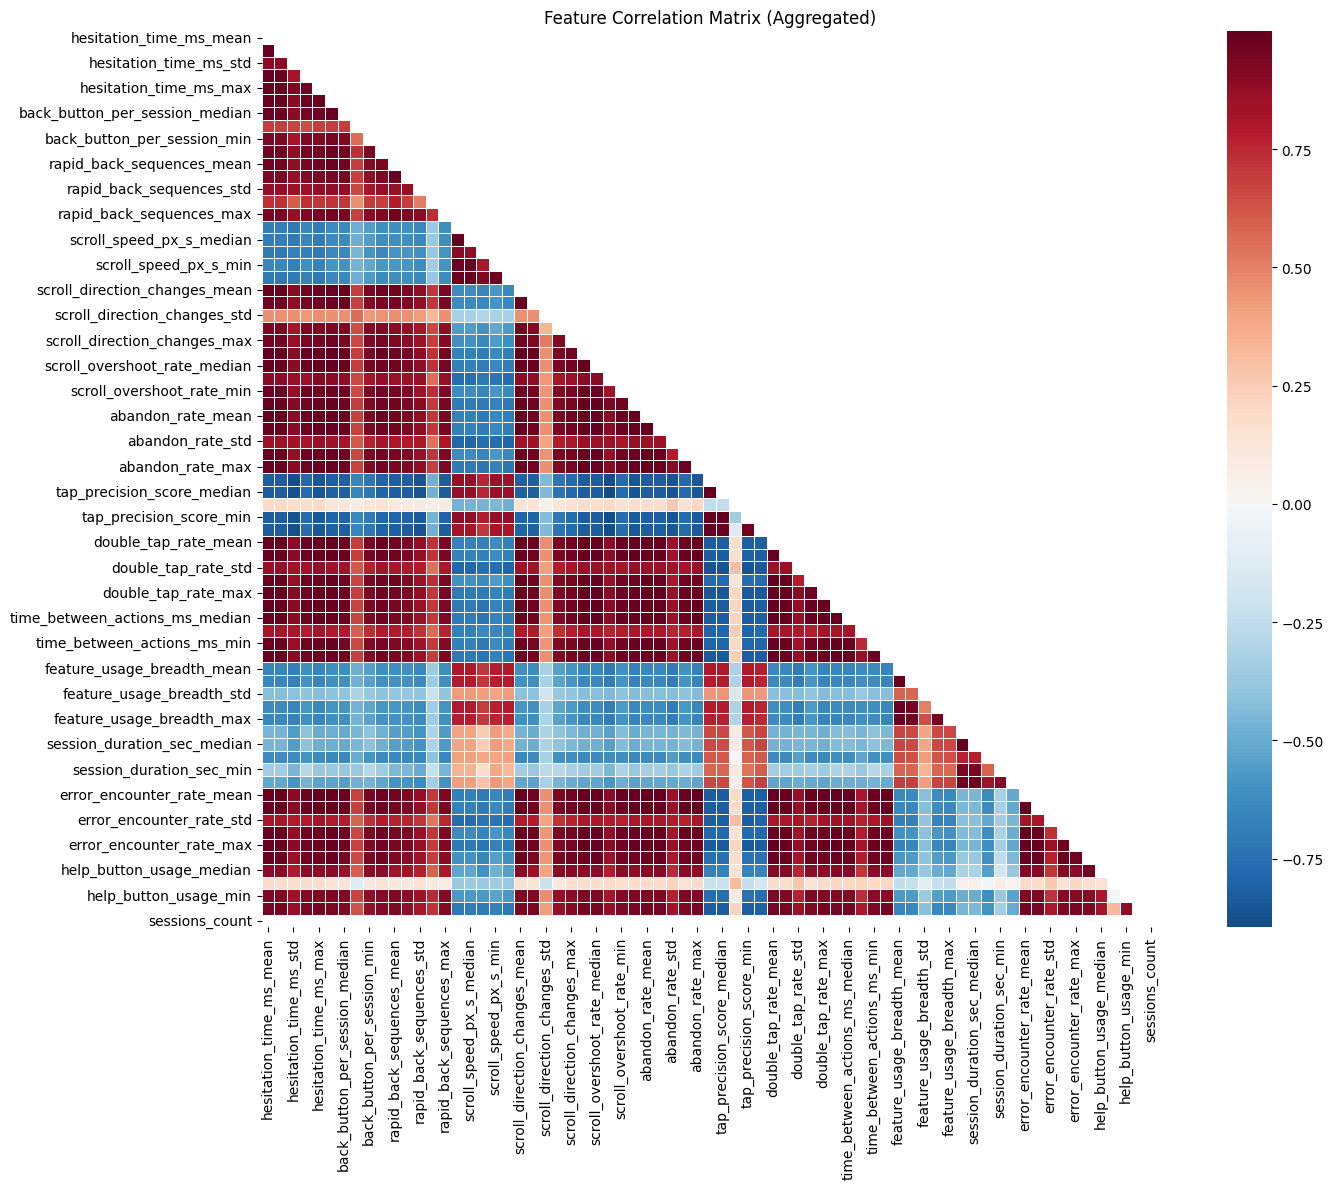

Highly correlated pairs (|r| > 0.9):
  hesitation_time_ms_mean <-> hesitation_time_ms_median: 0.999
  hesitation_time_ms_mean <-> hesitation_time_ms_std: 0.902
  hesitation_time_ms_mean <-> hesitation_time_ms_min: 0.983
  hesitation_time_ms_mean <-> hesitation_time_ms_max: 0.993
  hesitation_time_ms_mean <-> back_button_per_session_mean: 0.989
  hesitation_time_ms_mean <-> back_button_per_session_median: 0.974
  hesitation_time_ms_mean <-> back_button_per_session_min: 0.941
  hesitation_time_ms_mean <-> back_button_per_session_max: 0.969
  hesitation_time_ms_mean <-> rapid_back_sequences_mean: 0.965
  hesitation_time_ms_mean <-> rapid_back_sequences_median: 0.939
  hesitation_time_ms_mean <-> rapid_back_sequences_max: 0.946
  hesitation_time_ms_mean <-> scroll_direction_changes_mean: 0.988
  hesitation_time_ms_mean <-> scroll_direction_changes_median: 0.969
  hesitation_time_ms_mean <-> scroll_direction_changes_min: 0.934
  hesitation_time_ms_mean <-> scroll_direction_changes_max: 0.95

In [26]:
"""
Correlation heatmap antar fitur.
"""

corr_matrix = aggregated[feature_columns].corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='RdBu_r',
    center=0,
    annot=False,
    fmt='.2f',
    square=True,
    linewidths=0.5
)
plt.title('Feature Correlation Matrix (Aggregated)')
plt.tight_layout()
plt.show()

"""Identifikasi highly correlated pairs"""
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

if high_corr_pairs:
    print(f"Highly correlated pairs (|r| > 0.9):")
    for f1, f2, r in high_corr_pairs:
        print(f"  {f1} <-> {f2}: {r:.3f}")
else:
    print("No highly correlated feature pairs found (|r| > 0.9)")

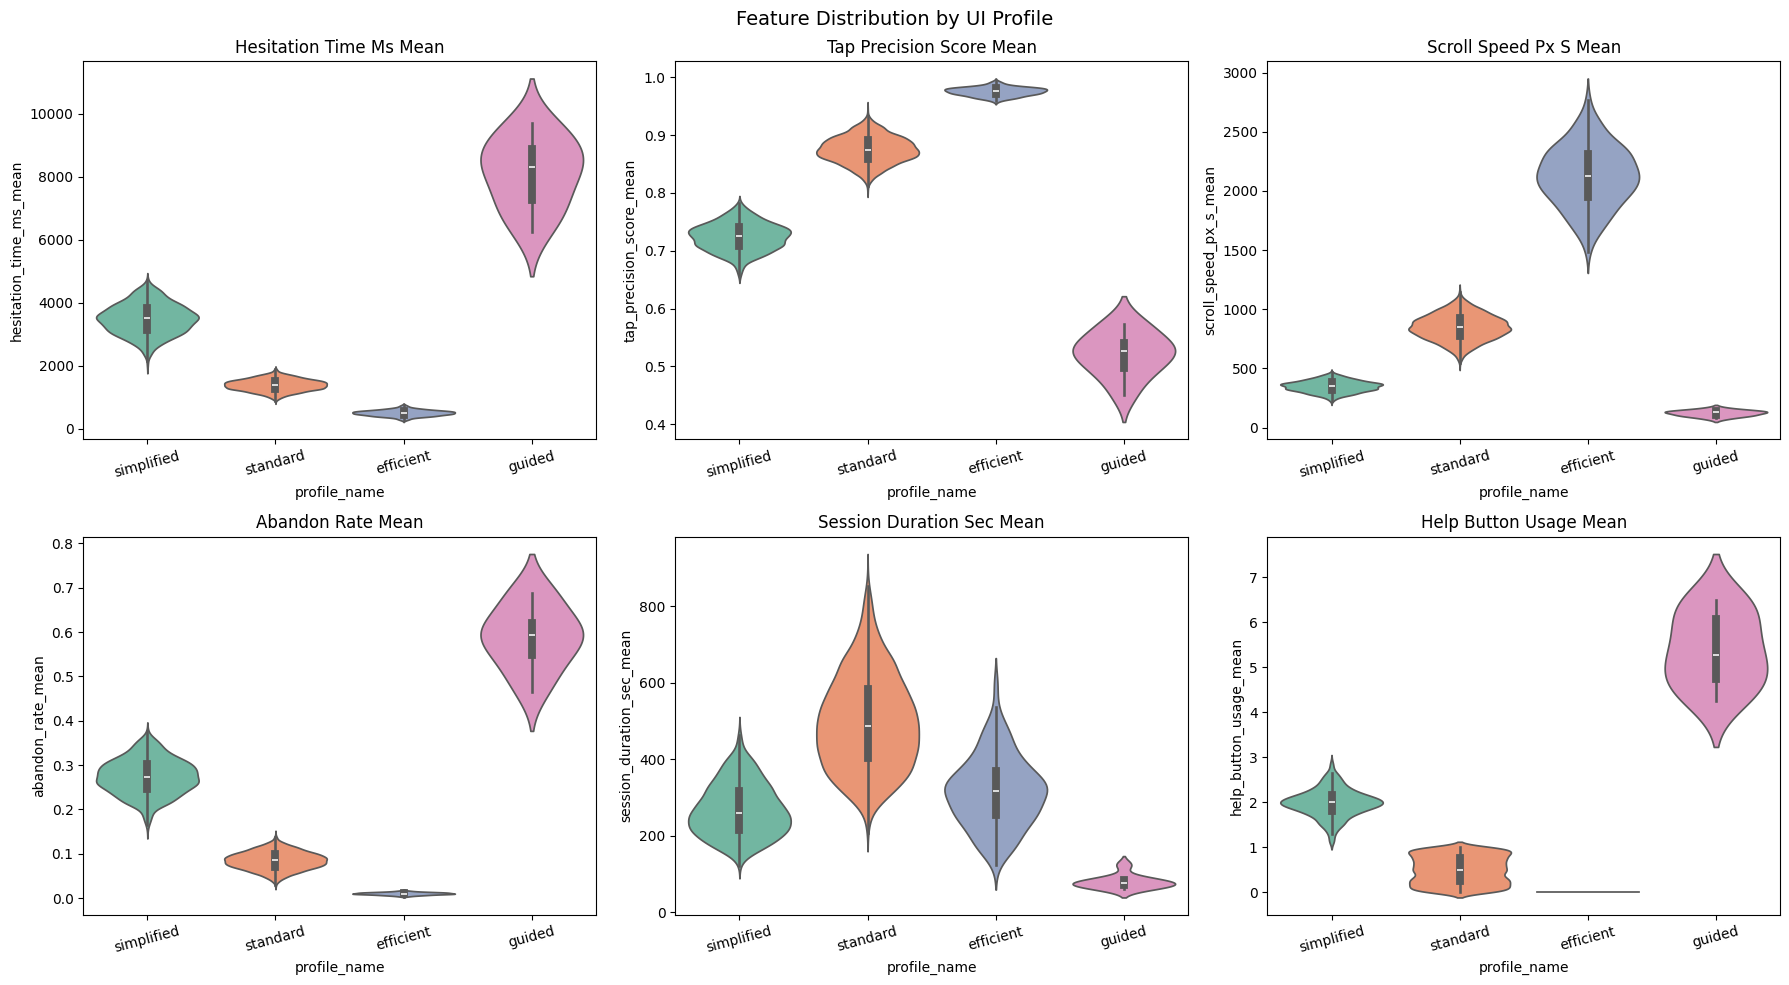

In [29]:
"""
Violin plots: distribusi fitur per UI profile.
"""

plot_features = ['hesitation_time_ms_mean', 'tap_precision_score_mean',
                 'scroll_speed_px_s_mean', 'abandon_rate_mean',
                 'session_duration_sec_mean', 'help_button_usage_mean']

available_features = [f for f in plot_features if f in aggregated.columns]

if available_features:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    profile_names = config['class_names']
    aggregated['profile_name'] = aggregated['ui_profile_label'].map(
        {i: name for i, name in enumerate(profile_names)}
    )

    for idx, feat in enumerate(available_features):
        sns.violinplot(
            data=aggregated,
            x='profile_name',
            y=feat,
            ax=axes[idx],
            palette='Set2',
            inner='box'
        )
        axes[idx].set_title(feat.replace('_', ' ').title())
        axes[idx].tick_params(axis='x', rotation=15)

    for idx in range(len(available_features), len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle('Feature Distribution by UI Profile', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("No matching features found for violin plots")

## Data Preprocessing

In [32]:
"""
DataLoader untuk LSTM/GRU training.
Class weights untuk menangani class imbalance.
"""

train_dataset = TensorDataset(X_train_seq, y_train)
val_dataset = TensorDataset(X_val_seq, y_val)
test_dataset = TensorDataset(X_test_seq, y_test)

train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True, drop_last=False)
val_loader = DataLoader(val_dataset, batch_size=config['batch_size'], shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=config['batch_size'], shuffle=False)

"""Compute class weights (inverse frequency)"""
unique_classes, class_counts = torch.unique(y_train, return_counts=True)
total_samples = y_train.shape[0]
class_weights = total_samples / (len(unique_classes) * class_counts.float())
class_weights = class_weights.to(device)

print(f"DataLoaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")
print(f"\nClass distribution (train):")
for cls, count, weight in zip(unique_classes, class_counts, class_weights):
    print(f"  Class {cls.item()} ({config['class_names'][cls.item()]:12s}): {count.item():5d} samples, weight={weight.item():.3f}")

DataLoaders created:
  Train batches: 55
  Val batches: 12
  Test batches: 12

Class distribution (train):
  Class 0 (guided      ):     7 samples, weight=125.000
  Class 1 (simplified  ):   863 samples, weight=1.014
  Class 2 (standard    ):  2498 samples, weight=0.350
  Class 3 (efficient   ):   132 samples, weight=6.629


## Model Architecture

### LSTM Classifier

In [33]:
class LSTMClassifier(nn.Module):
    """
    Bidirectional LSTM untuk klasifikasi UI profile dari sequence behavioral data.
    Input: (batch, seq_len, input_size) -> Output: (batch, num_classes)
    Menggunakan last hidden state dari kedua arah, diproses melalui FC layers.
    """

    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout, bidirectional):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )

        fc_input_size = hidden_size * self.num_directions
        self.fc = nn.Sequential(
            nn.Linear(fc_input_size, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout + 0.1),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        """Forward pass: LSTM -> last hidden -> FC layers"""
        lstm_out, (hidden, _) = self.lstm(x)

        if self.bidirectional:
            hidden_cat = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            hidden_cat = hidden[-1]

        out = self.fc(hidden_cat)
        return out

    def get_embeddings(self, x):
        """Ekstrak penultimate layer embeddings untuk visualisasi t-SNE"""
        lstm_out, (hidden, _) = self.lstm(x)

        if self.bidirectional:
            hidden_cat = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            hidden_cat = hidden[-1]

        """Return output setelah penultimate FC layer"""
        for layer in list(self.fc.children())[:-1]:
            hidden_cat = layer(hidden_cat)
        return hidden_cat


f"LSTMClassifier defined"

'LSTMClassifier defined'

### GRU Classifier

In [34]:
class GRUClassifier(nn.Module):
    """
    Bidirectional GRU untuk klasifikasi UI profile.
    Arsitektur identik dengan LSTM tapi menggunakan GRU cell (lebih sedikit parameter).
    """

    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout, bidirectional):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )

        fc_input_size = hidden_size * self.num_directions
        self.fc = nn.Sequential(
            nn.Linear(fc_input_size, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout + 0.1),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        """Forward pass: GRU -> last hidden -> FC layers"""
        gru_out, hidden = self.gru(x)

        if self.bidirectional:
            hidden_cat = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            hidden_cat = hidden[-1]

        out = self.fc(hidden_cat)
        return out

    def get_embeddings(self, x):
        """Ekstrak penultimate layer embeddings untuk visualisasi t-SNE"""
        gru_out, hidden = self.gru(x)

        if self.bidirectional:
            hidden_cat = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            hidden_cat = hidden[-1]

        for layer in list(self.fc.children())[:-1]:
            hidden_cat = layer(hidden_cat)
        return hidden_cat


f"GRUClassifier defined"

'GRUClassifier defined'

### Model Initialization

In [35]:
input_size = X_train_seq.shape[2]

lstm_model = LSTMClassifier(
    input_size=input_size,
    hidden_size=config['lstm_hidden_size'],
    num_layers=config['num_rnn_layers'],
    num_classes=config['num_classes'],
    dropout=config['rnn_dropout'],
    bidirectional=config['bidirectional']
).to(device)

gru_model = GRUClassifier(
    input_size=input_size,
    hidden_size=config['gru_hidden_size'],
    num_layers=config['num_rnn_layers'],
    num_classes=config['num_classes'],
    dropout=config['rnn_dropout'],
    bidirectional=config['bidirectional']
).to(device)

lstm_params = sum(p.numel() for p in lstm_model.parameters())
gru_params = sum(p.numel() for p in gru_model.parameters())
lstm_size_kb = sum(p.numel() * p.element_size() for p in lstm_model.parameters()) / 1024
gru_size_kb = sum(p.numel() * p.element_size() for p in gru_model.parameters()) / 1024

print(f"LSTM Classifier:")
print(f"  Parameters: {lstm_params:,}")
print(f"  Size: {lstm_size_kb:.2f} KB")
print(f"\nGRU Classifier:")
print(f"  Parameters: {gru_params:,}")
print(f"  Size: {gru_size_kb:.2f} KB")
print(f"\nParameter reduction (GRU vs LSTM): {(1 - gru_params/lstm_params)*100:.1f}%")

LSTM Classifier:
  Parameters: 165,700
  Size: 647.27 KB

GRU Classifier:
  Parameters: 130,628
  Size: 510.27 KB

Parameter reduction (GRU vs LSTM): 21.2%


## Training Functions

In [36]:
def train_one_epoch(model, loader, optimizer, criterion):
    """Single training epoch dengan gradient clipping"""
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    return avg_loss, accuracy, f1


@torch.no_grad()
def evaluate_model(model, loader, criterion):
    """Evaluasi model pada dataset tertentu"""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        total_loss += loss.item() * X_batch.size(0)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    return avg_loss, accuracy, f1


def train_rnn_model(model, model_name, train_loader, val_loader, config, class_weights):
    """
    Training loop lengkap dengan early stopping dan LR scheduler.
    Return: trained model, training history
    """
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config['learning_rate'],
        weight_decay=config['weight_decay']
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=8
    )

    history = {
        'train_loss': [], 'train_acc': [], 'train_f1': [],
        'val_loss': [], 'val_acc': [], 'val_f1': [], 'lr': []
    }

    best_val_f1 = 0
    patience_counter = 0
    best_state = None

    print(f"\n{'='*60}")
    print(f"Training {model_name}")
    print(f"{'='*60}")

    for epoch in range(config['num_epochs']):
        train_loss, train_acc, train_f1 = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc, val_f1 = evaluate_model(model, val_loader, criterion)

        current_lr = optimizer.param_groups[0]['lr']
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_f1'].append(train_f1)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        history['lr'].append(current_lr)

        scheduler.step(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            patience_counter = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{config['num_epochs']} | "
                  f"Train Loss: {train_loss:.4f} Acc: {train_acc:.3f} F1: {train_f1:.3f} | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_acc:.3f} F1: {val_f1:.3f} | "
                  f"LR: {current_lr:.6f}")

        if patience_counter >= config['patience']:
            print(f"\nEarly stopping at epoch {epoch+1} (best val F1: {best_val_f1:.4f})")
            break

    """Restore best model"""
    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(device)

    print(f"\n{model_name} training complete. Best Val F1: {best_val_f1:.4f}")
    return model, history


f"Training functions defined"

'Training functions defined'

## Training: LSTM

In [37]:
lstm_model, lstm_history = train_rnn_model(
    lstm_model,
    'LSTM Classifier',
    train_loader,
    val_loader,
    config,
    class_weights
)


Training LSTM Classifier
Epoch   1/100 | Train Loss: 0.5572 Acc: 0.907 F1: 0.936 | Val Loss: 0.1746 Acc: 0.999 F1: 0.998 | LR: 0.001000
Epoch  10/100 | Train Loss: 0.0032 Acc: 1.000 F1: 1.000 | Val Loss: 0.0008 Acc: 1.000 F1: 1.000 | LR: 0.001000

Early stopping at epoch 17 (best val F1: 1.0000)

LSTM Classifier training complete. Best Val F1: 1.0000


## Training: GRU

In [38]:
gru_model, gru_history = train_rnn_model(
    gru_model,
    'GRU Classifier',
    train_loader,
    val_loader,
    config,
    class_weights
)


Training GRU Classifier
Epoch   1/100 | Train Loss: 0.6649 Acc: 0.837 F1: 0.884 | Val Loss: 0.2478 Acc: 0.999 F1: 0.998 | LR: 0.001000
Epoch  10/100 | Train Loss: 0.0027 Acc: 1.000 F1: 1.000 | Val Loss: 0.0008 Acc: 1.000 F1: 1.000 | LR: 0.001000

Early stopping at epoch 17 (best val F1: 1.0000)

GRU Classifier training complete. Best Val F1: 1.0000


## Training: XGBoost

In [39]:
"""Compute sample weights untuk class imbalance"""
unique_classes_tab, class_counts_tab = np.unique(y_train_tab, return_counts=True)
total_tab = len(y_train_tab)
weight_map = {c: total_tab / (len(unique_classes_tab) * count) for c, count in zip(unique_classes_tab, class_counts_tab)}
sample_weights = np.array([weight_map[y] for y in y_train_tab])

xgb_model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=config['num_classes'],
    n_estimators=config['xgb_n_estimators'],
    max_depth=config['xgb_max_depth'],
    learning_rate=config['xgb_learning_rate'],
    subsample=config['xgb_subsample'],
    colsample_bytree=config['xgb_colsample_bytree'],
    eval_metric='mlogloss',
    random_state=config['random_seed'],
    use_label_encoder=False,
    tree_method='auto'
)

print("Training XGBoost Classifier...")
xgb_model.fit(
    X_train_tab, y_train_tab,
    sample_weight=sample_weights,
    eval_set=[(X_train_tab, y_train_tab), (X_val_tab, y_val_tab)],
    verbose=50
)

"""Evaluasi XGBoost pada validasi"""
xgb_val_preds = xgb_model.predict(X_val_tab)
xgb_val_f1 = f1_score(y_val_tab, xgb_val_preds, average='weighted')
xgb_val_acc = accuracy_score(y_val_tab, xgb_val_preds)

print(f"\nXGBoost Validation Results:")
print(f"  Accuracy: {xgb_val_acc:.4f}")
print(f"  Weighted F1: {xgb_val_f1:.4f}")

Training XGBoost Classifier...
[0]	validation_0-mlogloss:1.28876	validation_1-mlogloss:1.28895
[50]	validation_0-mlogloss:0.08361	validation_1-mlogloss:0.08395
[100]	validation_0-mlogloss:0.00771	validation_1-mlogloss:0.00778
[150]	validation_0-mlogloss:0.00127	validation_1-mlogloss:0.00130
[200]	validation_0-mlogloss:0.00075	validation_1-mlogloss:0.00077
[250]	validation_0-mlogloss:0.00070	validation_1-mlogloss:0.00073
[299]	validation_0-mlogloss:0.00070	validation_1-mlogloss:0.00073

XGBoost Validation Results:
  Accuracy: 1.0000
  Weighted F1: 1.0000


## Training Visualization

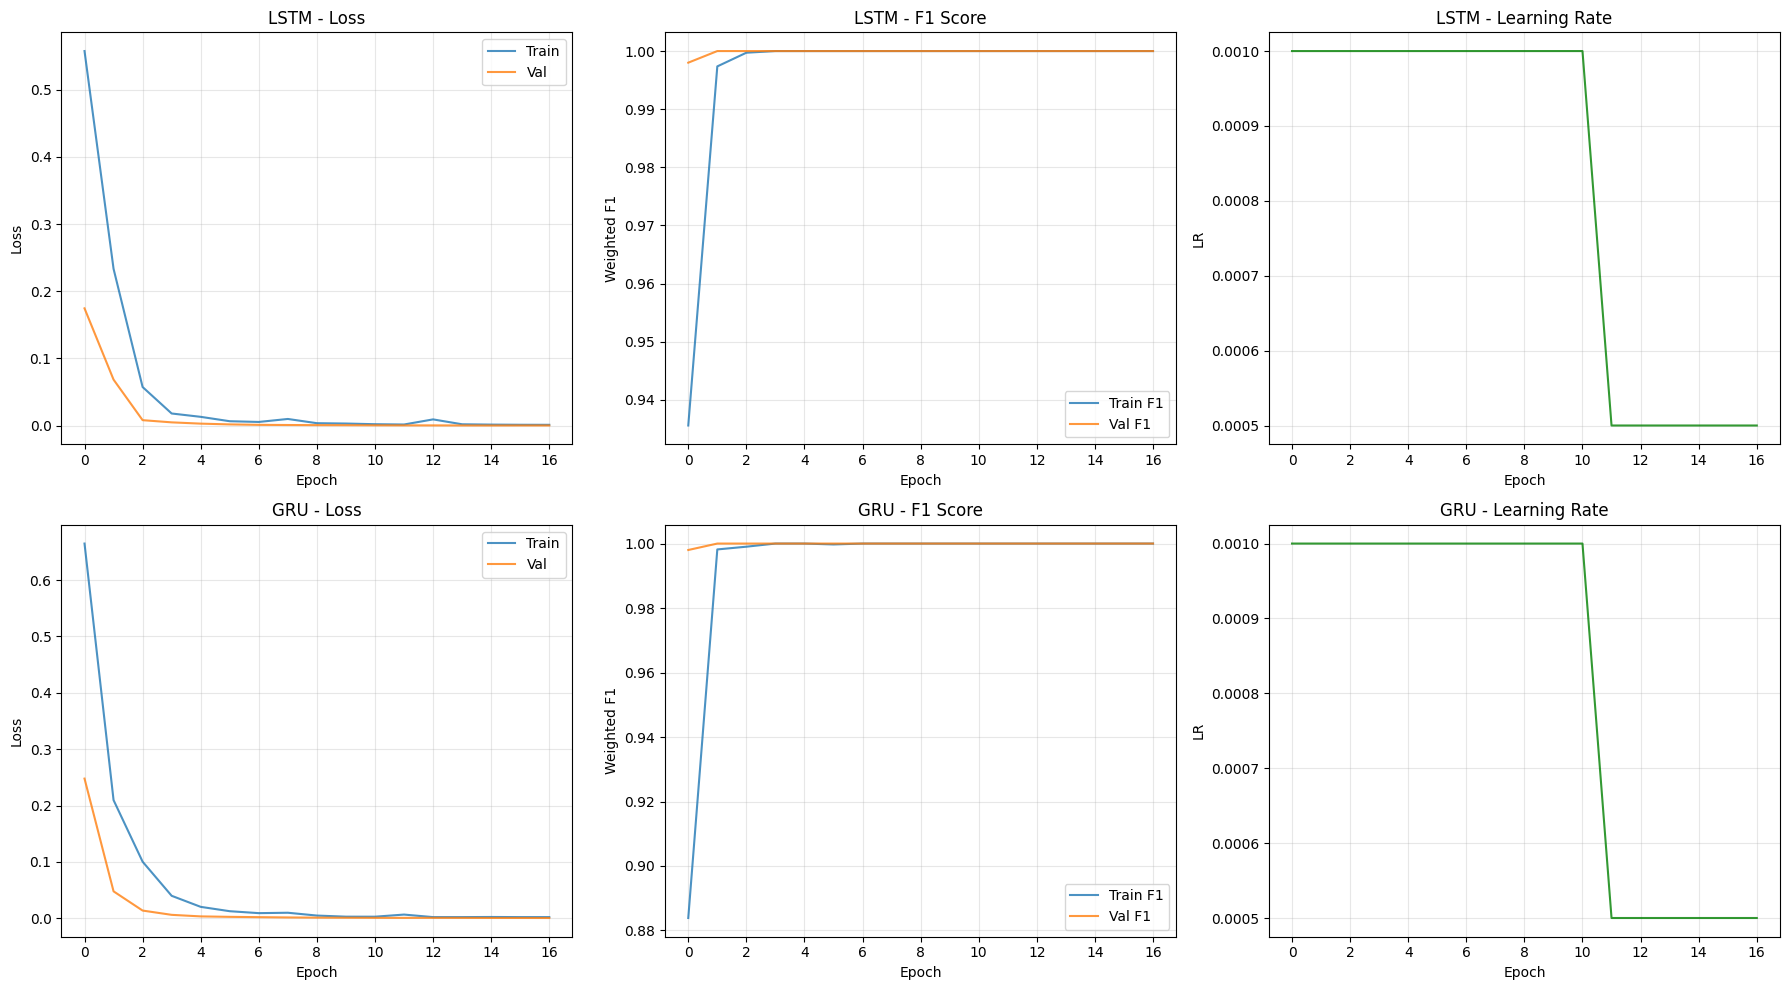

In [40]:
"""
Visualisasi loss curves dan F1 score untuk LSTM dan GRU.
"""

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

"""LSTM plots"""
axes[0, 0].plot(lstm_history['train_loss'], label='Train', alpha=0.8)
axes[0, 0].plot(lstm_history['val_loss'], label='Val', alpha=0.8)
axes[0, 0].set_title('LSTM - Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(lstm_history['train_f1'], label='Train F1', alpha=0.8)
axes[0, 1].plot(lstm_history['val_f1'], label='Val F1', alpha=0.8)
axes[0, 1].set_title('LSTM - F1 Score')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Weighted F1')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].plot(lstm_history['lr'], color='green', alpha=0.8)
axes[0, 2].set_title('LSTM - Learning Rate')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('LR')
axes[0, 2].grid(True, alpha=0.3)

"""GRU plots"""
axes[1, 0].plot(gru_history['train_loss'], label='Train', alpha=0.8)
axes[1, 0].plot(gru_history['val_loss'], label='Val', alpha=0.8)
axes[1, 0].set_title('GRU - Loss')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(gru_history['train_f1'], label='Train F1', alpha=0.8)
axes[1, 1].plot(gru_history['val_f1'], label='Val F1', alpha=0.8)
axes[1, 1].set_title('GRU - F1 Score')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Weighted F1')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].plot(gru_history['lr'], color='green', alpha=0.8)
axes[1, 2].set_title('GRU - Learning Rate')
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('LR')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Comparative Evaluation

In [41]:
"""
Evaluasi ketiga model pada test set.
(Accuracy, Weighted F1, Macro F1, dan per-class metrics)
"""

def get_test_predictions_rnn(model, loader):
    """Prediksi dari RNN model"""
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())
    return np.array(all_preds), np.array(all_labels)


"""LSTM predictions"""
lstm_preds, test_labels = get_test_predictions_rnn(lstm_model, test_loader)

"""GRU predictions"""
gru_preds, _ = get_test_predictions_rnn(gru_model, test_loader)

"""XGBoost predictions"""
xgb_preds = xgb_model.predict(X_test_tab)

"""Compute metrics untuk setiap model"""
results = {}
for model_name, preds, labels in [
    ('LSTM', lstm_preds, test_labels),
    ('GRU', gru_preds, test_labels),
    ('XGBoost', xgb_preds, y_test_tab)
]:
    results[model_name] = {
        'accuracy': accuracy_score(labels, preds),
        'weighted_f1': f1_score(labels, preds, average='weighted'),
        'macro_f1': f1_score(labels, preds, average='macro'),
        'per_class_precision': precision_score(labels, preds, average=None).tolist(),
        'per_class_recall': recall_score(labels, preds, average=None).tolist(),
        'per_class_f1': f1_score(labels, preds, average=None).tolist()
    }

"""Print comparison table"""
print("\n" + "=" * 60)
print("MODEL COMPARISON - TEST SET")
print("=" * 60)
print(f"{'Model':<12} {'Accuracy':>10} {'W-F1':>10} {'M-F1':>10}")
print("-" * 42)
for model_name, metrics in results.items():
    print(f"{model_name:<12} {metrics['accuracy']:>10.4f} {metrics['weighted_f1']:>10.4f} {metrics['macro_f1']:>10.4f}")

print(f"\nPer-class F1 Scores:")
print(f"{'Model':<12} {'Guided':>10} {'Simplified':>12} {'Standard':>10} {'Efficient':>12}")
print("-" * 56)
for model_name, metrics in results.items():
    f1s = metrics['per_class_f1']
    print(f"{model_name:<12} {f1s[0]:>10.4f} {f1s[1]:>12.4f} {f1s[2]:>10.4f} {f1s[3]:>12.4f}")


MODEL COMPARISON - TEST SET
Model          Accuracy       W-F1       M-F1
------------------------------------------
LSTM             1.0000     1.0000     1.0000
GRU              1.0000     1.0000     1.0000
XGBoost          1.0000     1.0000     1.0000

Per-class F1 Scores:
Model            Guided   Simplified   Standard    Efficient
--------------------------------------------------------
LSTM             1.0000       1.0000     1.0000       1.0000
GRU              1.0000       1.0000     1.0000       1.0000
XGBoost          1.0000       1.0000     1.0000       1.0000


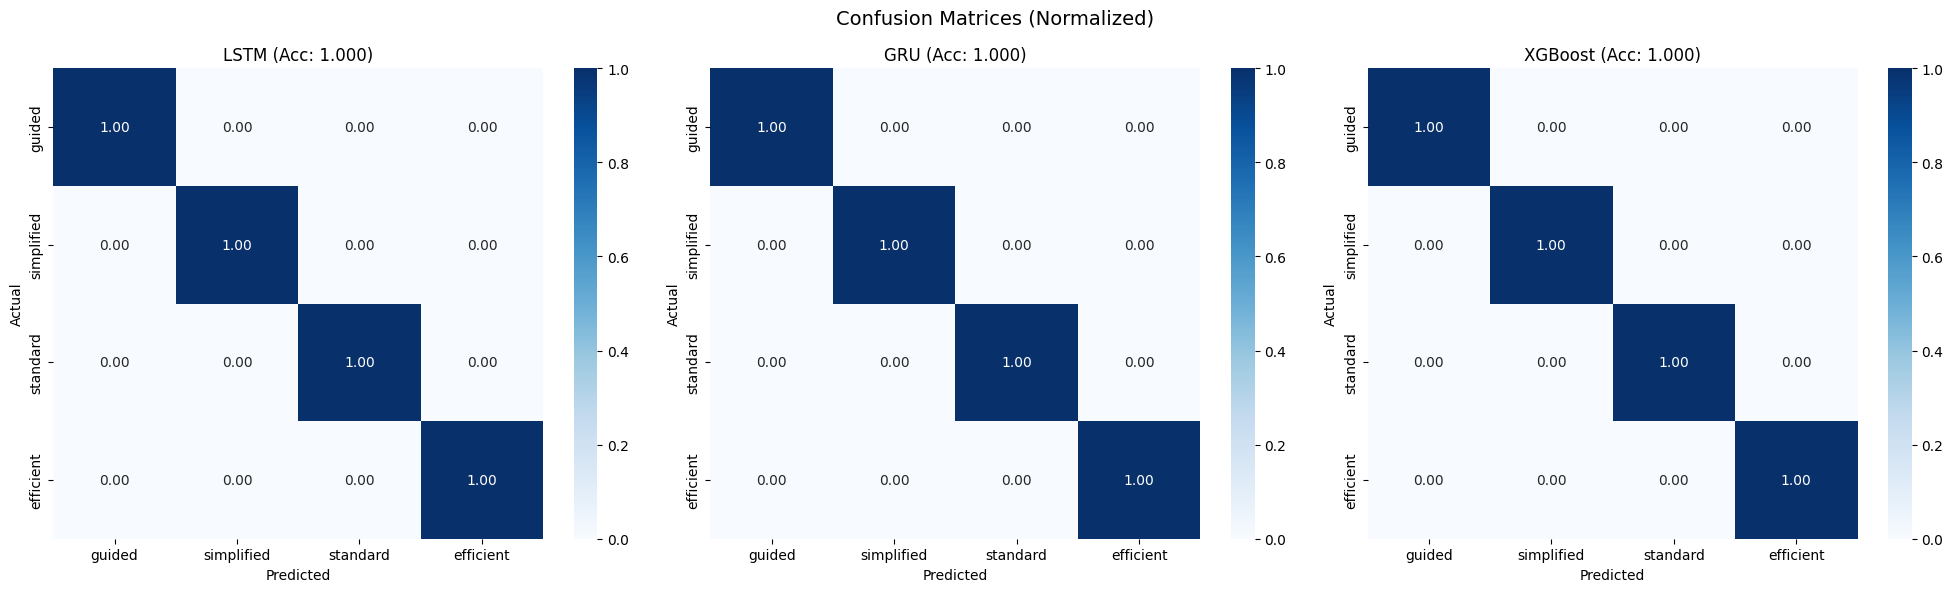

In [42]:
"""
Confusion matrix heatmaps untuk ketiga model.
"""

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, (model_name, preds, labels) in enumerate([
    ('LSTM', lstm_preds, test_labels),
    ('GRU', gru_preds, test_labels),
    ('XGBoost', xgb_preds, y_test_tab)
]):
    cm = confusion_matrix(labels, preds)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        xticklabels=config['class_names'],
        yticklabels=config['class_names'],
        ax=axes[idx]
    )
    axes[idx].set_title(f'{model_name} (Acc: {results[model_name]["accuracy"]:.3f})')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.suptitle('Confusion Matrices (Normalized)', fontsize=14)
plt.tight_layout()
plt.show()

## Best Model Selection

In [43]:
best_model_name = max(results, key=lambda k: results[k]['weighted_f1'])
best_metrics = results[best_model_name]

print(f"Best model: {best_model_name}")
print(f"  Weighted F1: {best_metrics['weighted_f1']:.4f}")
print(f"  Accuracy: {best_metrics['accuracy']:.4f}")
print(f"  Macro F1: {best_metrics['macro_f1']:.4f}")

if best_model_name == 'LSTM':
    best_rnn_model = lstm_model
elif best_model_name == 'GRU':
    best_rnn_model = gru_model
else:
    best_rnn_model = None

f"Selected {best_model_name} as the best model with Weighted F1 = {best_metrics['weighted_f1']:.4f}"

Best model: LSTM
  Weighted F1: 1.0000
  Accuracy: 1.0000
  Macro F1: 1.0000


'Selected LSTM as the best model with Weighted F1 = 1.0000'

## Feature Importance (XGBoost)

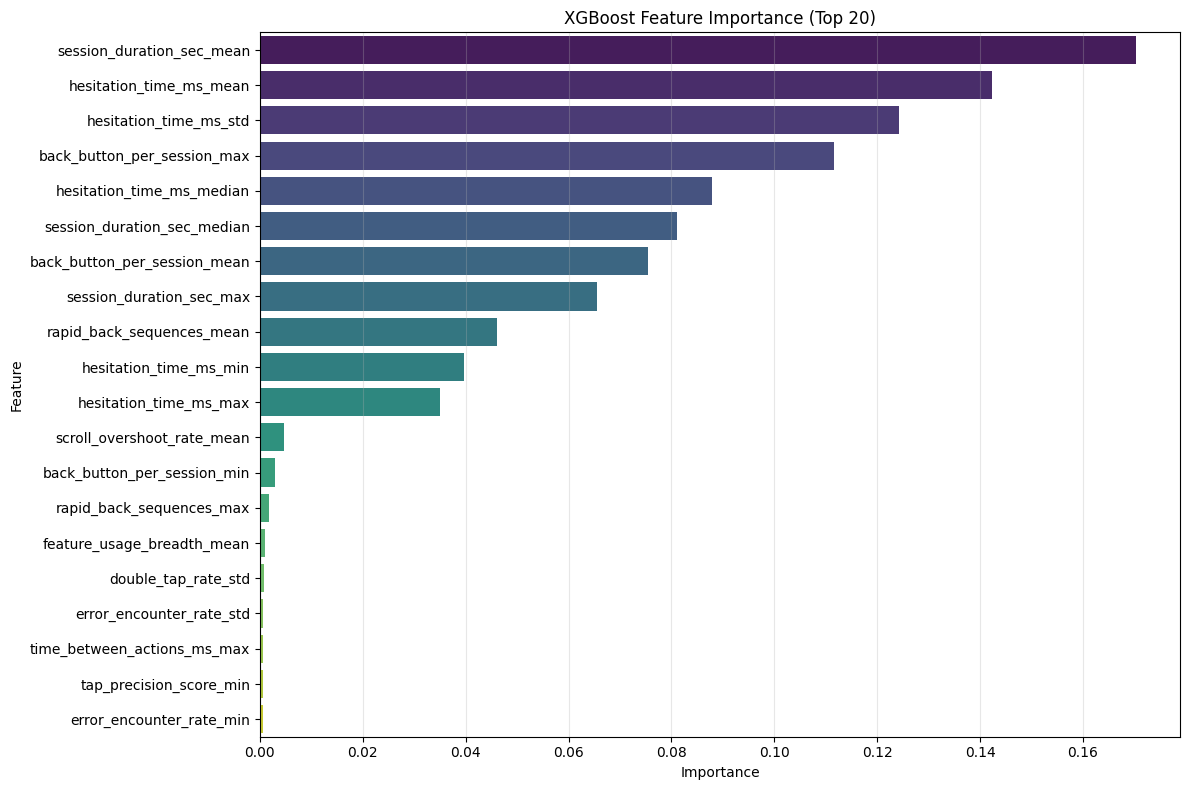

Top 10 most important features:
  session_duration_sec_mean               : 0.1703
  hesitation_time_ms_mean                 : 0.1423
  hesitation_time_ms_std                  : 0.1243
  back_button_per_session_max             : 0.1115
  hesitation_time_ms_median               : 0.0879
  session_duration_sec_median             : 0.0811
  back_button_per_session_mean            : 0.0754
  session_duration_sec_max                : 0.0654
  rapid_back_sequences_mean               : 0.0461
  hesitation_time_ms_min                  : 0.0397


In [44]:
importances = xgb_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': tab_feature_cols,
    'importance': importances
}).sort_values('importance', ascending=False)

"""Plot top 20 features"""
top_n = 20
top_features = feature_importance_df.head(top_n)

plt.figure(figsize=(12, 8))
sns.barplot(
    data=top_features,
    x='importance',
    y='feature',
    palette='viridis'
)
plt.title(f'XGBoost Feature Importance (Top {top_n})')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print(f"Top 10 most important features:")
for _, row in feature_importance_df.head(10).iterrows():
    print(f"  {row['feature']:40s}: {row['importance']:.4f}")

## Per-Class Analysis

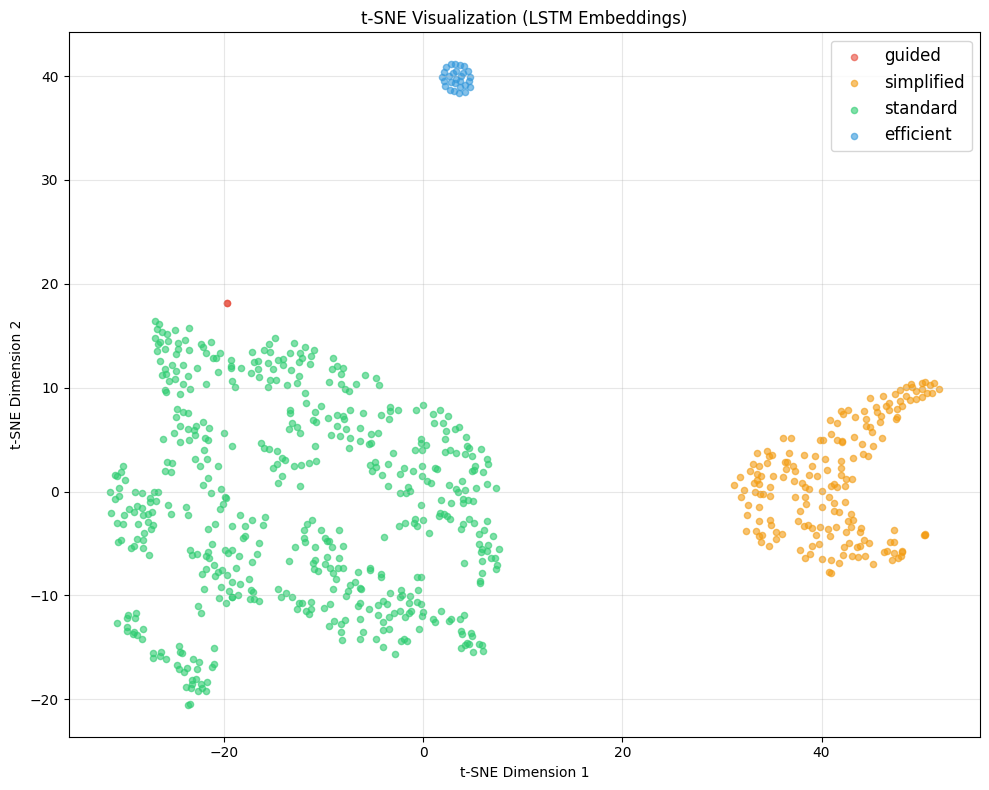

In [45]:
"""
t-SNE visualisasi dari embeddings model RNN terbaik.
"""

if best_rnn_model is not None:
    best_rnn_model.eval()
    all_embeddings = []
    all_labels_tsne = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            emb = best_rnn_model.get_embeddings(X_batch)
            all_embeddings.append(emb.cpu().numpy())
            all_labels_tsne.extend(y_batch.numpy())

    embeddings = np.concatenate(all_embeddings, axis=0)
    labels_tsne = np.array(all_labels_tsne)

    tsne = TSNE(n_components=2, random_state=config['random_seed'], perplexity=30)
    embeddings_2d = tsne.fit_transform(embeddings)

    plt.figure(figsize=(10, 8))
    colors = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']
    for cls_idx, cls_name in enumerate(config['class_names']):
        mask = labels_tsne == cls_idx
        plt.scatter(
            embeddings_2d[mask, 0],
            embeddings_2d[mask, 1],
            c=colors[cls_idx],
            label=cls_name,
            alpha=0.6,
            s=20
        )

    plt.title(f't-SNE Visualization ({best_model_name} Embeddings)')
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Best model is XGBoost, skipping t-SNE embedding visualization")

In [46]:
"""
Classification report detail untuk model terbaik.
"""

if best_model_name == 'XGBoost':
    best_preds = xgb_preds
    best_labels = y_test_tab
elif best_model_name == 'LSTM':
    best_preds = lstm_preds
    best_labels = test_labels
else:
    best_preds = gru_preds
    best_labels = test_labels

print(f"\nDetailed Classification Report ({best_model_name}):")
print("=" * 60)
print(classification_report(
    best_labels,
    best_preds,
    target_names=config['class_names']
))


Detailed Classification Report (LSTM):
              precision    recall  f1-score   support

      guided       1.00      1.00      1.00         2
  simplified       1.00      1.00      1.00       185
    standard       1.00      1.00      1.00       535
   efficient       1.00      1.00      1.00        28

    accuracy                           1.00       750
   macro avg       1.00      1.00      1.00       750
weighted avg       1.00      1.00      1.00       750



## Model Export

In [48]:
"""
Export LSTM dan GRU model ke PyTorch checkpoint dan ONNX.
"""

models_dir = f'{models_path}'
Path(models_dir).mkdir(parents=True, exist_ok=True)

"""Save LSTM checkpoint"""
torch.save({
    'model_state_dict': lstm_model.state_dict(),
    'config': config,
    'architecture': {
        'type': 'LSTMClassifier',
        'input_size': input_size,
        'hidden_size': config['lstm_hidden_size'],
        'num_layers': config['num_rnn_layers'],
        'num_classes': config['num_classes'],
        'bidirectional': config['bidirectional']
    },
    'test_metrics': results['LSTM']
}, f'{models_dir}/lstm_classifier.pt')
print(f"Saved: lstm_classifier.pt")

"""Save GRU checkpoint"""
torch.save({
    'model_state_dict': gru_model.state_dict(),
    'config': config,
    'architecture': {
        'type': 'GRUClassifier',
        'input_size': input_size,
        'hidden_size': config['gru_hidden_size'],
        'num_layers': config['num_rnn_layers'],
        'num_classes': config['num_classes'],
        'bidirectional': config['bidirectional']
    },
    'test_metrics': results['GRU']
}, f'{models_dir}/gru_classifier.pt')
print(f"Saved: gru_classifier.pt")

"""Sequence length dari config"""
seq_length = config['sessions_per_user']

"""Export LSTM to ONNX"""
lstm_model.eval()
dummy_input = torch.randn(1, seq_length, input_size).to(device)

torch.onnx.export(
    lstm_model,
    dummy_input,
    f'{models_dir}/lstm_classifier.onnx',
    opset_version=13,
    input_names=['input'],
    output_names=['output'],
    dynamo=False,
    dynamic_axes={
        'input': {0: 'batch_size'},
        'output': {0: 'batch_size'}
    }
)
print(f"Saved: lstm_classifier.onnx")

"""Export GRU to ONNX"""
gru_model.eval()
torch.onnx.export(
    gru_model,
    dummy_input,
    f'{models_dir}/gru_classifier.onnx',
    opset_version=13,
    input_names=['input'],
    output_names=['output'],
    dynamo=False,
    dynamic_axes={
        'input': {0: 'batch_size'},
        'output': {0: 'batch_size'}
    }
)
print(f"Saved: gru_classifier.onnx")

Saved: lstm_classifier.pt
Saved: gru_classifier.pt
Saved: lstm_classifier.onnx
Saved: gru_classifier.onnx


In [49]:
"""
Export XGBoost model ke JSON format dan deployment parameters.
"""

"""XGBoost native JSON format"""
xgb_model.save_model(f'{models_dir}/xgboost_classifier.json')
print(f"Saved: xgboost_classifier.json")

"""Export deployment params untuk inference pipeline"""
deployment_params = {
    'sequence_length': config['sessions_per_user'],
    'num_features': config['num_session_features'],
    'num_classes': config['num_classes'],
    'class_names': config['class_names'],
    'feature_names': feature_cols,
    'scaler_mean': seq_scaler.mean_.tolist(),
    'scaler_scale': seq_scaler.scale_.tolist(),
    'tab_feature_cols': tab_feature_cols,
    'tab_scaler_mean': tab_scaler.mean_.tolist(),
    'tab_scaler_scale': tab_scaler.scale_.tolist(),
    'best_model': best_model_name,
    'best_model_metrics': best_metrics
}

with open(f'{models_dir}/deployment_params.json', 'w') as f:
    json.dump(deployment_params, f, indent=2)
print(f"Saved: deployment_params.json")

Saved: xgboost_classifier.json
Saved: deployment_params.json


In [50]:
"""
Verifikasi ukuran file model.
"""

model_files = [
    'lstm_classifier.pt',
    'lstm_classifier.onnx',
    'gru_classifier.pt',
    'gru_classifier.onnx',
    'xgboost_classifier.json',
    'deployment_params.json'
]

print("Model file sizes:")
print("=" * 50)
for filename in model_files:
    filepath = f'{models_dir}/{filename}'
    if os.path.exists(filepath):
        size_bytes = os.path.getsize(filepath)
        size_kb = size_bytes / 1024
        size_mb = size_kb / 1024
        status = 'OK' if size_mb < 1.0 else 'WARN: > 1MB'
        print(f"  {filename:30s}: {size_kb:8.1f} KB ({size_mb:.3f} MB) [{status}]")
    else:
        print(f"  {filename:30s}: NOT FOUND")

Model file sizes:
  lstm_classifier.pt            :    658.3 KB (0.643 MB) [OK]
  lstm_classifier.onnx          :    654.3 KB (0.639 MB) [OK]
  gru_classifier.pt             :    521.3 KB (0.509 MB) [OK]
  gru_classifier.onnx           :    516.3 KB (0.504 MB) [OK]
  xgboost_classifier.json       :    678.7 KB (0.663 MB) [OK]
  deployment_params.json        :      7.2 KB (0.007 MB) [OK]


## ONNX Verification

In [52]:
import onnx
import onnxruntime as ort

"""Verify LSTM ONNX"""
onnx_model = onnx.load(f'{models_dir}/lstm_classifier.onnx')
onnx.checker.check_model(onnx_model)
print("LSTM ONNX model is valid")

"""Compare ONNX vs PyTorch predictions"""
test_input = X_test_seq[:5].numpy()

"""PyTorch prediction"""
lstm_model.eval()
with torch.no_grad():
    pt_output = lstm_model(X_test_seq[:5].to(device)).cpu().numpy()

"""ONNX prediction"""
ort_session = ort.InferenceSession(f'{models_dir}/lstm_classifier.onnx')
ort_output = ort_session.run(None, {'input': test_input})[0]

"""Compare"""
max_diff = np.abs(pt_output - ort_output).max()
print(f"\nLSTM ONNX vs PyTorch max difference: {max_diff:.8f}")
print(f"Match: {'YES' if max_diff < 1e-4 else 'NO - investigate'}")

"""Verify GRU ONNX"""
onnx_gru = onnx.load(f'{models_dir}/gru_classifier.onnx')
onnx.checker.check_model(onnx_gru)
print(f"\nGRU ONNX model is valid")

gru_model.eval()
with torch.no_grad():
    pt_gru_output = gru_model(X_test_seq[:5].to(device)).cpu().numpy()

ort_gru_session = ort.InferenceSession(f'{models_dir}/gru_classifier.onnx')
ort_gru_output = ort_gru_session.run(None, {'input': test_input})[0]

max_diff_gru = np.abs(pt_gru_output - ort_gru_output).max()
print(f"GRU ONNX vs PyTorch max difference: {max_diff_gru:.8f}")
print(f"Match: {'YES' if max_diff_gru < 1e-4 else 'NO - investigate'}")

LSTM ONNX model is valid

LSTM ONNX vs PyTorch max difference: 0.00008297
Match: YES

GRU ONNX model is valid
GRU ONNX vs PyTorch max difference: 0.00011659
Match: NO - investigate


## Summary Report

In [53]:
summary = {
    'task': 'Adaptive Cognitive UI - Data Generation and Model Training',
    'timestamp': datetime.now().isoformat(),
    'data': {
        'num_users': config['num_users'],
        'sessions_per_user': config['sessions_per_user'],
        'total_sessions': config['num_users'] * config['sessions_per_user'],
        'num_features': config['num_session_features'],
        'split_ratio': '70/15/15',
        'train_size': len(train_idx),
        'val_size': len(val_idx),
        'test_size': len(test_idx)
    },
    'models': {
        'LSTM': {
            'parameters': lstm_params,
            'size_kb': lstm_size_kb,
            'epochs_trained': len(lstm_history['train_loss']),
            'test_accuracy': results['LSTM']['accuracy'],
            'test_weighted_f1': results['LSTM']['weighted_f1'],
            'test_macro_f1': results['LSTM']['macro_f1'],
            'per_class_f1': results['LSTM']['per_class_f1']
        },
        'GRU': {
            'parameters': gru_params,
            'size_kb': gru_size_kb,
            'epochs_trained': len(gru_history['train_loss']),
            'test_accuracy': results['GRU']['accuracy'],
            'test_weighted_f1': results['GRU']['weighted_f1'],
            'test_macro_f1': results['GRU']['macro_f1'],
            'per_class_f1': results['GRU']['per_class_f1']
        },
        'XGBoost': {
            'n_estimators': config['xgb_n_estimators'],
            'max_depth': config['xgb_max_depth'],
            'test_accuracy': results['XGBoost']['accuracy'],
            'test_weighted_f1': results['XGBoost']['weighted_f1'],
            'test_macro_f1': results['XGBoost']['macro_f1'],
            'per_class_f1': results['XGBoost']['per_class_f1']
        }
    },
    'best_model': best_model_name,
    'best_model_weighted_f1': best_metrics['weighted_f1'],
    'class_names': config['class_names'],
    'exports': {
        'raw_data': ['ui-behavior-sessions.csv', 'ui-profiles.csv'],
        'models': ['lstm_classifier.pt', 'lstm_classifier.onnx',
                   'gru_classifier.pt', 'gru_classifier.onnx',
                   'xgboost_classifier.json', 'deployment_params.json']
    },
    'deployment_ready': True
}


print('\n' + '=' * 60)
print('ADAPTIVE COGNITIVE UI - COMPLETE')
print('=' * 60)
print(f"\nBest Model: {best_model_name}")
print(f"  Accuracy:    {best_metrics['accuracy']:.4f}")
print(f"  Weighted F1: {best_metrics['weighted_f1']:.4f}")
print(f"  Macro F1:    {best_metrics['macro_f1']:.4f}")
print(f"\nAll models comparison:")
for name, metrics in results.items():
    marker = ' <-- BEST' if name == best_model_name else ''
    print(f"  {name:10s}: Acc={metrics['accuracy']:.4f}, W-F1={metrics['weighted_f1']:.4f}{marker}")
print(f"\nFiles saved to:")
print(f"  Raw data:  {datas_path}/")
print(f"  Models:    {models_dir}/")
print(f"\nReady for on-device deployment via ONNX")


ADAPTIVE COGNITIVE UI - COMPLETE

Best Model: LSTM
  Accuracy:    1.0000
  Weighted F1: 1.0000
  Macro F1:    1.0000

All models comparison:
  LSTM      : Acc=1.0000, W-F1=1.0000 <-- BEST
  GRU       : Acc=1.0000, W-F1=1.0000
  XGBoost   : Acc=1.0000, W-F1=1.0000

Files saved to:
  Raw data:  ../datas/
  Models:    ../models/

Ready for on-device deployment via ONNX
